---
title: From Linear Regression to Nonlinear Regression
---

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

### Recap: Linear Regression

We have so far studied (multiple) linear regression models. The linear model is written as: 
\begin{align*}
    y = X \beta + \epsilon
\end{align*}
where the data is represented by the $n \times 1$ vector $y$ and the $n \times (m+1)$ matrix $X$ whose first column is the column of ones. The unknown parameter vector is the $(m+1) \times 1$ vector $\beta$ and the error vector $\epsilon$ has i.i.d $N(0, \sigma^2)$ components. Equivalently, we can write $\epsilon \sim N_n(0, \sigma^2 I_n)$ (this is the multivariate normal distribution with mean vector 0 and covariance matrix $\sigma^2 I_n$). 

In the last lab, we considered the problem of fitting a cubic trend function to the US GDP time series dataset. If $y_t$ denotes the US GDP corresponding to time $t$, we are fitting the model: 
\begin{align*}
    y_t = \beta_0 + \beta_1 t + \beta_2 t^2 + \beta_3 t^3 + \epsilon_t
\end{align*}
This is a special case of multiple linear regression with
\begin{equation*}
   y = \begin{pmatrix} y_1\\ y_2 \\ \cdot \\ \cdot \\ \cdot \\ y_n \end{pmatrix} ~~~
   X = \begin{pmatrix} 1 & 1 & 1 & 1 \\ 1 & 2 & 2^2 & 2^3 \\ 1 & 3 & 3^2 & 3^3 \\ \cdot & \cdot & \cdot & \cdot \\ \cdot & \cdot & \cdot & \cdot \\ \cdot & \cdot & \cdot & \cdot \\ 1 & n & n^2 & n^3 \end{pmatrix} ~~~ \beta = \begin{pmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \\ \beta_3 \end{pmatrix} ~ ~ ~ \epsilon = \begin{pmatrix} \epsilon_1 \\ \epsilon_2 \\ \cdot \\ \cdot \\ \cdot \\ \epsilon_n \end{pmatrix}
\end{equation*}
We fit this model in statsmodels using the OLS function. 

  observation_date      GDP
0       1947-01-01  243.164
1       1947-04-01  245.968
2       1947-07-01  249.585
3       1947-10-01  259.745
4       1948-01-01  265.742
5       1948-04-01  272.567
6       1948-07-01  279.196
7       1948-10-01  280.366
8       1949-01-01  275.034
9       1949-04-01  271.351


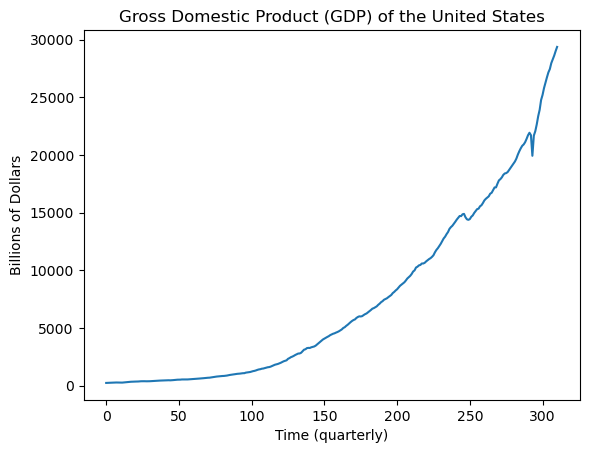

In [11]:
#Here is the US GDP dataset:
gdp = pd.read_csv('GDP-Jan2025FRED.csv')
print(gdp.head(10)) 
plt.plot(gdp['GDP'])
plt.xlabel("Time (quarterly)")
plt.ylabel("Billions of Dollars")
plt.title("Gross Domestic Product (GDP) of the United States")
plt.show()

In [12]:
y = gdp['GDP']
n = len(y)
x = np.arange(1, n + 1)
x2 = x ** 2
x3 = x ** 3
X = np.column_stack([np.ones(n),x, x2, x3])

md = sm.OLS(y, X).fit()
print(md.summary())

                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 2.000e+04
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:19:25   Log-Likelihood:                -2402.2
No. Observations:                 311   AIC:                             4812.
Df Residuals:                     307   BIC:                             4827.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        292.1841    126.498      2.310      0.0

### Residual Sum of Squares (RSS) in linear regression

One of the most important quantities in linear regression is the Residual Sum of Squares (RSS). This is defined as the sum of the squares of residuals. The residuals are defined by: 
\begin{align*}
   e_i = y_i - \hat{y}_i = y_i - \hat{\beta}_0 - \hat{\beta}_1 x_{i1} - \dots - \hat{\beta}_m x_{im}. 
\end{align*}
In vector form, the residual vector with components $e_1, \dots, e_n$ is given by
\begin{align*}
   e = y - \hat{y}
\end{align*}
where $\hat{y} = X \hat{\beta}$ is the vector of fitted values. 

The Residual Sum of Squares (RSS) is defined as 
\begin{align*}
   RSS = \sum_{i=1}^n e_i^2 = \|e\|^2 = \|y - X \hat{\beta}\|^2. 
\end{align*}
In class, we used the notation $S(\beta)$ for the squares function: 
\begin{align*}
   S(\beta) = \|y - X \beta\|^2. 
\end{align*}
We can then see that RSS is the smallest possible value of $S(\beta)$. It is also the value of $S(\beta)$ evaluated at $\beta = \hat{\beta}$ where $\hat{\beta}$ is the least squares estimate: 
\begin{align*}
   RSS = \inf_{\beta} S(\beta) = S(\hat{\beta}). 
\end{align*}
RSS can be used as a measure of the goodness of fit of a linear regression model. However, one needs to be careful in comparing RSS values across models with different numbers of parameters (in that case, the RSS of a bigger model i.e., the model with more parameters will usually be lower). 

The RSS can be computed using the OLS output in the following way. 

In [9]:
#One can compute the residual sum of squares (RSS) in two ways:
#The first way is to use the residuals from the model: 
#The residuals are the differences between the observed values and the fitted values.
residuals = md.resid
#the residual sum of squares (RSS) is the sum of the squared residuals:
rss_md = np.sum(md.resid ** 2)
print(rss_md)
#The second way is to use the model's attribute `ssr`, which stands for "sum of squared residuals":
#SSR (Sum of Squared Residuals) is another name for RSS (Residual Sum of Squares). 
print(md.ssr)

93203230.55790283
93203230.55790283


## Nonlinear Regression Models

Next we shall study models where some parameters are appearing in a nonlinear fashion. A simple example is given by: 
\begin{align*}
   y_t = \beta_0 + \beta_1 t + \beta_2 (t - c)_+ + \epsilon_t. 
\end{align*}
As a motivating example for this model, we consider the following dataset on annual U.S. corn yields from 1866 to 1955, measured in bushels per acre (this dataset is taken from USDA NASS, Crop Production Historical Track Records). 

   year  yield_bushels_per_acre
0  1866                    24.3
1  1867                    24.7
2  1868                    26.2
3  1869                    21.8
4  1870                    29.3
5  1871                    27.2
6  1872                    29.4
7  1873                    22.9
8  1874                    22.2
9  1875                    27.7
    year  yield_bushels_per_acre
80  1946                    37.2
81  1947                    28.6
82  1948                    43.0
83  1949                    38.2
84  1950                    38.2
85  1951                    36.9
86  1952                    41.8
87  1953                    40.7
88  1954                    39.4
89  1955                    42.0


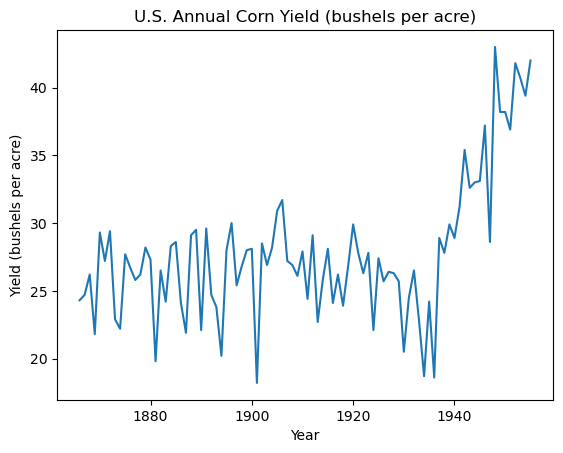

In [15]:
corn = pd.read_csv('USCornYield_1866_1955.csv')
print(corn.head(10))
print(corn.tail(10))
tme = np.arange(1866, 1956)
plt.plot(tme, corn['yield_bushels_per_acre'], label='U.S. Corn Yield')
plt.xlabel('Year')
plt.ylabel('Yield (bushels per acre)')
plt.title('U.S. Annual Corn Yield (bushels per acre)')
plt.show()

We work with corn yields in their original units, bushels per acre. Thus, a slope measures the annual increase in yield in bushels per acre per year. We do not take logarithms for this example.

If we fit a linear regression model to this data, we will get an estimate of the overall annual increase in corn yield: 
\begin{align*}
   y_t = \beta_0 + \beta_1 t + \epsilon_t
\end{align*}
Here $t = 1$ corresponds to 1866. 

                              OLS Regression Results                              
Dep. Variable:     yield_bushels_per_acre   R-squared:                       0.260
Model:                                OLS   Adj. R-squared:                  0.252
Method:                     Least Squares   F-statistic:                     30.98
Date:                    Mon, 14 Sep 2026   Prob (F-statistic):           2.78e-07
Time:                            22:25:23   Log-Likelihood:                -261.63
No. Observations:                      90   AIC:                             527.3
Df Residuals:                          88   BIC:                             532.3
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

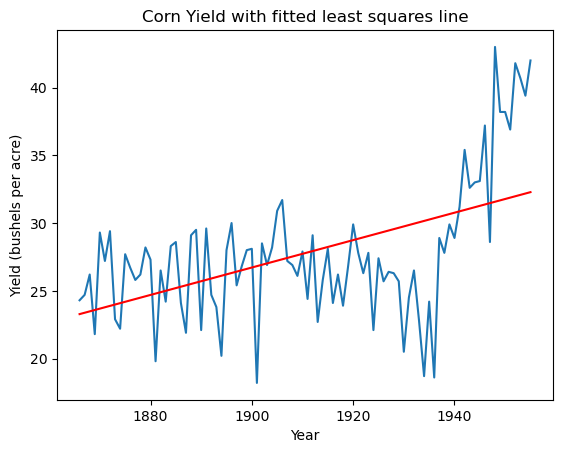

In [17]:
y = corn['yield_bushels_per_acre']
n = len(y)
x = np.arange(1, n+1)
X = np.column_stack((np.ones(n), x))
linreg = sm.OLS(y, X).fit()
print(linreg.summary())
plt.plot(tme, y, label='Yield (bushels per acre)')
plt.plot(tme, linreg.fittedvalues, color='red', label='Fitted least squares line')
plt.xlabel('Year')
plt.ylabel('Yield (bushels per acre)')
plt.title('Corn Yield with fitted least squares line')
plt.show()

The fitted slope coefficient is approximately 0.1012. Its interpretation is that corn yield increases, on average over this whole period, by about 0.10 bushels per acre each year.

The simple linear regression model does not describe the change from nearly constant yields to increasing yields. The quality of the fit can be assessed using the Residual Sum of Squares (RSS).

In [18]:
rss_lm = np.sum(linreg.resid ** 2)
print(rss_lm)

1765.1484468041324


The simple linear regression model uses the same annual increase throughout the period. The plot suggests that yields were approximately constant in the earlier years, but began increasing in the later years. We can instead consider the following model:
\begin{equation*}
  y_t = \beta_0 + \beta_1 t + \beta_2 (t - c)_+ + \epsilon_t
\end{equation*}
This model uses $\beta_1$ for the slope before $c$, and $\beta_1 + \beta_2$ for the slope after $c$.

If $c$ is known, then this is again linear regression (but now it is multiple linear regression as opposed to simple linear regression), and we can fit this model as follows. In this code, we are hard-coding the value of $c$. 

                              OLS Regression Results                              
Dep. Variable:     yield_bushels_per_acre   R-squared:                       0.314
Model:                                OLS   Adj. R-squared:                  0.298
Method:                     Least Squares   F-statistic:                     19.88
Date:                    Mon, 14 Sep 2026   Prob (F-statistic):           7.74e-08
Time:                            22:26:23   Log-Likelihood:                -258.27
No. Observations:                      90   AIC:                             522.5
Df Residuals:                          87   BIC:                             530.0
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

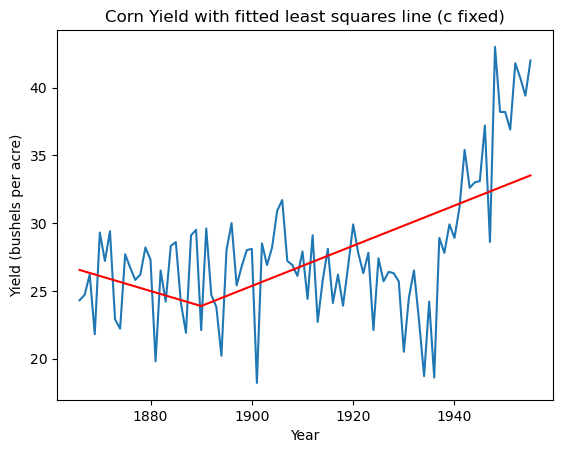

In [19]:
c = 25 #some arbitrary value
x = np.arange(1, n+1)
x_c = np.maximum(0, x - c)
X = np.column_stack((np.ones(n), x, x_c))
linreg_c_fixed = sm.OLS(y, X).fit()
print(linreg_c_fixed.summary())
plt.plot(tme, y, label='Yield (bushels per acre)')
plt.plot(tme, linreg_c_fixed.fittedvalues, color='red', label='Fitted least squares line')
plt.xlabel('Year')
plt.ylabel('Yield (bushels per acre)')
plt.title('Corn Yield with fitted least squares line (c fixed)')
plt.show()

To assess the quality of fit of this model, we again look at the residual sum of squares. 

In [7]:
rss_lm_c_fixed = np.sum(linreg_c_fixed.resid ** 2)
print(rss_lm_c_fixed, rss_lm)

1637.9835634183632 1765.1484468041324


The RSS decreases from about 1765.15 to 1637.98. While this is an improvement, it is quite possible that a different value of $c$ would give an even smaller value of RSS. Below we try a different value of $c$. 

In [20]:
c = 75 #some arbitrary value
x = np.arange(1, n+1)
x_c = np.maximum(0, x - c)
X = np.column_stack((np.ones(n), x, x_c))
linreg_c_fixed = sm.OLS(y, X).fit()
rss_lm_c_fixed = np.sum(linreg_c_fixed.resid ** 2)
print(rss_lm_c_fixed)

874.8665318763375


This RSS value is much smaller compared to the previous ones. It is natural here to vary $c$ over all its possible values, and then to find the $c$ which gives the smallest value of RSS. This will be our method of estimating $c$. More precisely, we estimate $c$ by the following method:
1. For each fixed value of $c$, calculate RSS
2. Use the value of $c$ with the smallest RSS as the estimate

The following function calculates the value of RSS for each fixed value of $c$. 

In [21]:
def rss(c):
    x = np.arange(1, n+1)
    x_c = np.maximum(0, x - c)
    X = np.column_stack((np.ones(n), x, x_c))
    md = sm.OLS(y, X).fit()
    rss = np.sum(md.resid ** 2)
    return rss

We compute $RSS(c)$ on a grid of 1000 candidate values between 1 and $n$, as follows. The grid includes noninteger values, so the estimated change point can fall between two observation years.

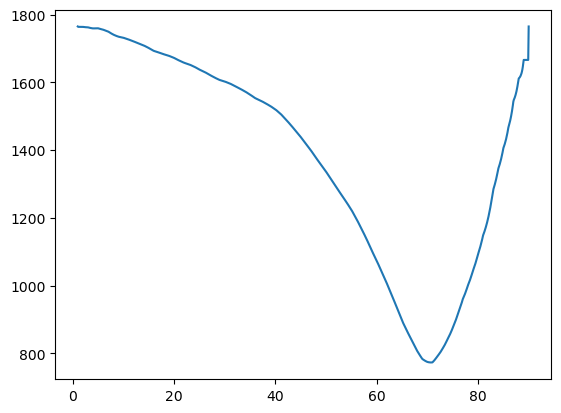

In [22]:
num_c_vals = 1000 #this is the number of different values of c we will try
allcvals = np.linspace(1, n, num_c_vals)
rssvals = np.array([rss(c) for c in allcvals])
plt.plot(allcvals, rssvals)
plt.show()

The estimate $\hat{c}$ is obtained by minimizing $RSS(c)$ as follows. 

In [23]:
c_hat = allcvals[np.argmin(rssvals)]
print(c_hat)
print(c_hat - 1 + tme[0]) #this is the estimated year when the slope changes
rss_smallest = np.min(rssvals)
print(rss_smallest, rss_lm, rss_lm_c_fixed)


70.75675675675676
1935.7567567567567
772.9049497954343 1765.1484468041324 874.8665318763375


Note that the value of RSS at $\hat{c}$ is much smaller than the RSS at the previously tried $c$ values. 

If we run a linear regression with $c$ fixed at $\hat{c}$, the fitted values will approximate the data much better. 

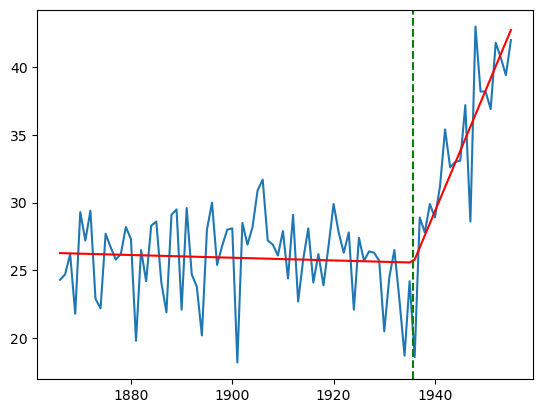

In [24]:
c = c_hat
x = np.arange(1, n+1)
x_c = np.maximum(0, x - c)
X = np.column_stack((np.ones(n), x, x_c))
md = sm.OLS(y, X).fit()
plt.plot(tme, y)
plt.plot(tme, md.fittedvalues, color = 'red')
plt.axvline(c_hat - 1 + tme[0], color='green', linestyle='--')
plt.show()

In the nonlinear regression model, we also have the parameters $\beta_0, \beta_1, \beta_2$. These can be estimated by simply fixing $c = \hat{c}$, and then running linear regression. This is done as follows:

In [25]:
#Estimates of other parameters: 
c = c_hat
x = np.arange(1, n+1)
x_c = np.maximum(0, x - c)
X = np.column_stack((np.ones(n), x, x_c))
md = sm.OLS(y, X).fit()
print(md.params) #this gives estimates of beta_0, beta_1, beta_2 

const    26.282432
x1       -0.010014
x2        0.902100
dtype: float64


The estimated change year (corresponding to $\hat{c}$) is approximately 1935.76. The estimate of $\hat{\beta}_1$ is about $-0.010$, and the estimate of $\hat{\beta}_2$ is about $0.902$. Thus, the fitted annual increase in corn yield is approximately
\begin{align*}
  -0.010 \quad &\text{bushels per acre per year before the change},\\
  -0.010 + 0.902 = 0.892 \quad &\text{bushels per acre per year after the change}.
\end{align*}
In other words, the fitted trend is nearly flat before about 1936, and yield subsequently increases by approximately 0.89 bushels per acre each year.

This timing is consistent with the historical adoption of hybrid corn (read about this). 

For the linear regression model, we have studied inference (uncertainty quantification) for the parameters $\beta$. In this nonlinear regression model, one can ask for uncertainty quantification for the parameter $c$ also. This will be covered in lectures this week. 

## Another Nonlinear Regression Model

The `wtloss` dataset in the R package MASS contains 52 measurements of one person's body weight over an eight-month weight rehabilitation programme. Weight is recorded in kilograms and time in elapsed days. The data were supplied by Dr T. Davies, Adelaide.


    Days  Weight
0      0  184.35
1      4  182.51
2      7  180.45
3      7  179.91
4     11  177.91
5     18  175.81
6     24  173.11
7     30  170.06
8     32  169.31
9     43  165.10
10    46  163.11
11    60  158.30
12    64  155.80
13    70  154.31
14    71  153.86
15    71  154.20
16    73  152.20
17    74  152.80
18    84  150.30
19    88  147.80
20    95  146.10
21   102  145.60
22   106  142.50
23   109  142.30
24   115  139.40
25   122  137.90
26   133  133.70
27   137  133.70
28   140  133.30
29   143  131.20
30   147  133.00
31   148  132.20
32   149  130.80
33   150  131.30
34   153  129.00
35   156  127.90
36   161  126.90
37   164  127.70
38   165  129.50
39   165  128.40
40   170  125.40
41   176  124.90
42   179  124.90
43   198  118.20
44   214  118.20
45   218  115.30
46   221  115.70
47   225  116.00
48   233  115.50
49   238  112.60
50   241  114.00
51   246  112.60


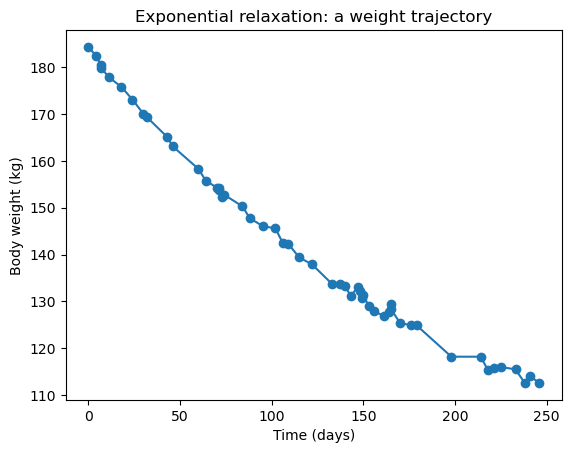

In [27]:
wtloss = pd.read_csv('WeightLoss_0_246days.csv')
print(wtloss)
y = wtloss['Weight']
n = len(y)
x = wtloss['Days'].to_numpy()
tme = x
plt.plot(tme, y, 'o-')
plt.xlabel('Time (days)')
plt.ylabel('Body weight (kg)')
plt.title('Exponential relaxation: a weight trajectory')
plt.show()

This is an example of a time series dataset where the time is not regular i.e., the gaps between the observations is not uniform. So each data point here comes with a specific time stamp (the time stamp is also part of the dataset). 

Let us first fit a simple linear regression to this dataset. 

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     1665.
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           4.72e-40
Time:                        23:04:35   Log-Likelihood:                -139.93
No. Observations:                  52   AIC:                             283.9
Df Residuals:                      50   BIC:                             287.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        176.8902      0.988    179.103      0.0

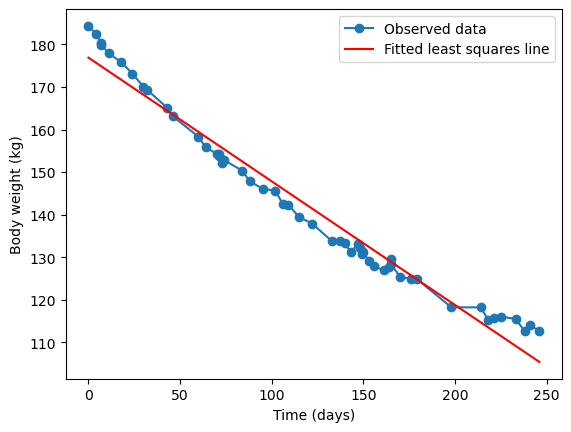

In [28]:
X = np.column_stack((np.ones(n), x))
linreg = sm.OLS(y, X).fit()
print(linreg.summary())
plt.plot(tme, y, 'o-', label='Observed data')
plt.plot(tme, linreg.fittedvalues, color='red', label='Fitted least squares line')
plt.xlabel('Time (days)')
plt.ylabel('Body weight (kg)')
plt.legend()
plt.show()

Here is the RSS for this model: 

In [29]:
rss_lm = np.sum(linreg.resid ** 2)
print(rss_lm)

662.1403861707598


From the dataset, it is clear that the weight loss is initially steep but it is gradually flattening over time. This behaviour is better captured by the model: 
\begin{align*}
   y_t=\beta_0+\beta_1 e^{-ct}+\epsilon_t. 
\end{align*}
Here $t=0$ is the beginning of the record.

- $\beta_0$ is the horizontal asymptote of the fitted curve.
- $\beta_0+\beta_1$ is the fitted initial weight.
- $c$ controls how quickly the curve approaches its asymptote. 
For positive $\beta_1$ and $c$, the curve decreases and gradually flattens. 

For fixed $c$, this is linear regression with explanatory variable $e^{-ct}$. We first hard-code $c=0.002$ per day and then fit the linear regression. 

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     4460.
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           1.49e-50
Time:                        23:08:02   Log-Likelihood:                -114.79
No. Observations:                  52   AIC:                             233.6
Df Residuals:                      50   BIC:                             237.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.7507      2.223     -2.137      0.0

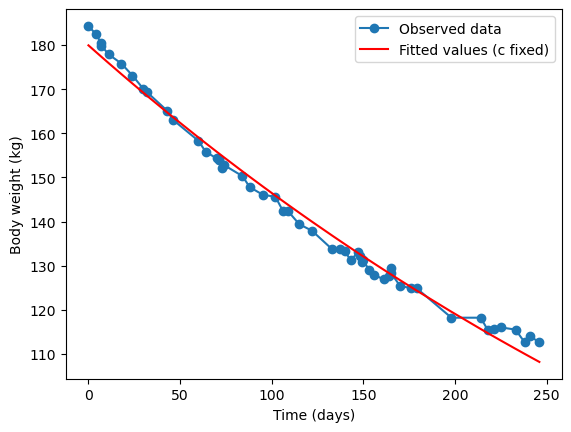

In [30]:
c = 0.002 #some arbitrary value
x_c = np.exp(-c * x)
X = np.column_stack((np.ones(n), x_c))
linreg_c_fixed = sm.OLS(y, X).fit()
print(linreg_c_fixed.summary())
plt.plot(tme, y, 'o-', label='Observed data')
plt.plot(tme, linreg_c_fixed.fittedvalues, color='red', label='Fitted values (c fixed)')
plt.xlabel('Time (days)')
plt.ylabel('Body weight (kg)')
plt.legend()
plt.show()

Here is the RSS for this fixed $c$ model, compared to the RSS for the simple linear trend model. 

In [31]:
rss_lm_c_fixed = np.sum(linreg_c_fixed.resid ** 2)
print(rss_lm_c_fixed, rss_lm)

251.77772269274698 662.1403861707598


With $c=0.002$, RSS is about 251.78, compared with 662.14 for the straight line. Let us now try a different value of $c$: $c=0.01$ to see how changing the nonlinear parameter changes the fit.

In [32]:
c = 0.01 #another arbitrary value
x_c = np.exp(-c * x)
X = np.column_stack((np.ones(n), x_c))
linreg_c_fixed = sm.OLS(y, X).fit()
rss_lm_c_fixed = np.sum(linreg_c_fixed.resid ** 2)
print(rss_lm_c_fixed)

585.3691417017087


Now the RSS has become worse (compared to $c = 0.002$) which means that the fit must be worse also. 

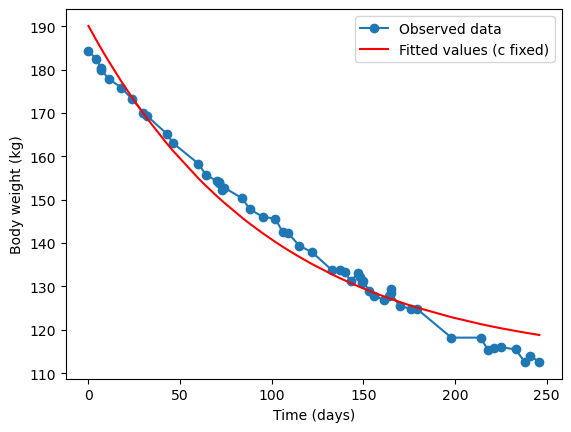

In [33]:
plt.plot(tme, y, 'o-', label='Observed data')
plt.plot(tme, linreg_c_fixed.fittedvalues, color='red', label='Fitted values (c fixed)')
plt.xlabel('Time (days)')
plt.ylabel('Body weight (kg)')
plt.legend()
plt.show()

### Search for the value of $c$ with the smallest RSS

We use exactly the same method as for the corn-yield data:

1. For each fixed value of $c$, fit the linear coefficients and calculate RSS.
2. Choose the value of $c$ with the smallest RSS.

The function below retains the structure of `rss(c)` in the original lab. The data vector `y`, its length `n`, and the actual observation times `x` have already been defined.

In [34]:
def rss(c):
    x_c = np.exp(-c * x)
    X = np.column_stack((np.ones(n), x_c))
    md = sm.OLS(y, X).fit()
    rss = np.sum(md.resid ** 2)
    return rss

We evaluate 1000 candidate rates from 0.0001 to 0.03 per day. We exclude $c=0$, where the exponential column would equal the intercept column.

The fitted rate should be inside the search interval. If a minimum occurs at an endpoint, the interval needs to be reconsidered.

Below we plot the RSS as $c$ varies over this range. 

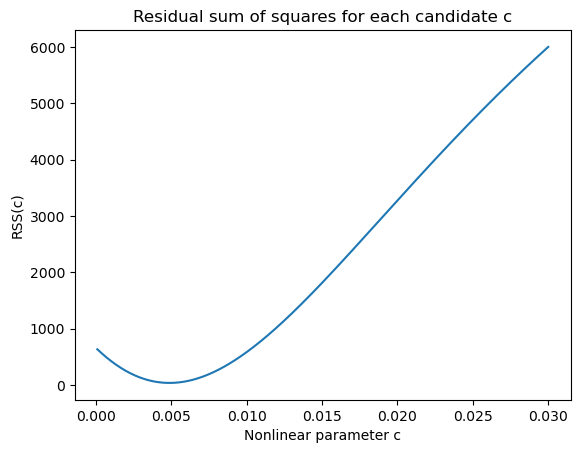

In [35]:
num_c_vals = 1000 #this is the number of different values of c we will try
allcvals = np.linspace(0.0001, 0.03, num_c_vals)
rssvals = np.array([rss(c) for c in allcvals])
plt.plot(allcvals, rssvals)
plt.xlabel('Nonlinear parameter c')
plt.ylabel('RSS(c)')
plt.title('Residual sum of squares for each candidate c')
plt.show()

The estimate $\hat c$ is obtained by minimizing $RSS(c)$ over the grid.

In [36]:
c_hat = allcvals[np.argmin(rssvals)]
print(c_hat)
rss_smallest = np.min(rssvals)
print(rss_smallest, rss_lm, rss_lm_c_fixed)

0.004888788788788789
39.24516434939978 662.1403861707598 585.3691417017087


The best grid value is $\hat c\approx 0.004889$, which is inside the search interval. Its RSS is about 39.25. We now fix $c=\hat c$ and fit the linear coefficients again.

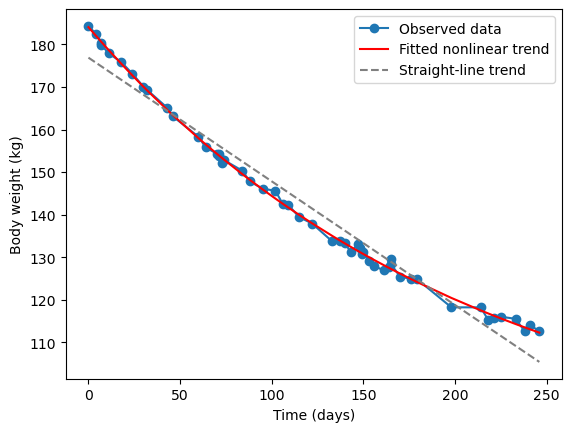

In [37]:
c = c_hat
x_c = np.exp(-c * x)
X = np.column_stack((np.ones(n), x_c))
md = sm.OLS(y, X).fit()
plt.plot(tme, y, 'o-', label='Observed data')
plt.plot(tme, md.fittedvalues, color='red', label='Fitted nonlinear trend')
plt.plot(tme, linreg.fittedvalues, color='gray', linestyle='--', label='Straight-line trend')
plt.xlabel('Time (days)')
plt.ylabel('Body weight (kg)')
plt.legend()
plt.show()

The estimates of $\beta_0$ and $\beta_1$ are obtained from this OLS fit.

In [38]:
print(md.params) #estimates of beta_0 and beta_1
beta0_hat, beta1_hat = md.params
print('Fitted value at time 0:', beta0_hat + beta1_hat)

const     81.427616
x1       102.636219
dtype: float64
Fitted value at time 0: 184.0638348838226


### Plotting the residuals for the nonlinear regression model

A smaller RSS does not by itself establish that a model is adequate. Below, we plot the residuals against the actual measurement times to look for systematic departures from the fitted curve.

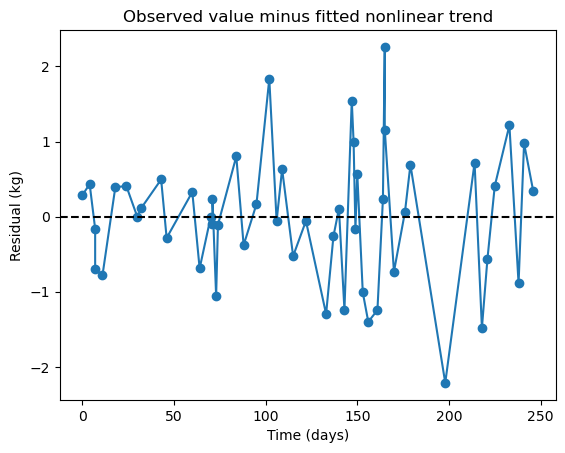

In [39]:
residuals = md.resid
plt.plot(tme, residuals, 'o-')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Time (days)')
plt.ylabel('Residual (kg)')
plt.title('Observed value minus fitted nonlinear trend')
plt.show()

The residuals are mostly small, within a few kilograms, and do not show the broad curvature missed by a straight line. This supports the exponential curve as a description of the observed trend. It does not prove independence or normality of the errors.

### Cross Validation

Below we compare this nonlinear regression model with linear regression for prediction. We use the first 42 observations, through day 176, for fitting and the remaining 10 observations, days 179–246, for checking predictions.

Note now that $c$ has to be estimated only on the training dataset. 

In [41]:
n_train = 42
x_train = x[:n_train]
y_train = y.iloc[:n_train]
x_test = x[n_train:]
y_test = y.iloc[n_train:]

def rss_train(c):
    x_c = np.exp(-c * x_train)
    X = np.column_stack((np.ones(n_train), x_c))
    md = sm.OLS(y_train, X).fit()
    return np.sum(md.resid ** 2)

rssvals_train = np.array([rss_train(c) for c in allcvals])
c_hat_train = allcvals[np.argmin(rssvals_train)]
print('c estimated using only the earlier observations:', c_hat_train)

c estimated using only the earlier observations: 0.004888788788788789


Predictions are obtained for the future observations in the following way. 

In [42]:
c = c_hat_train
X_train = np.column_stack((np.ones(n_train), np.exp(-c * x_train)))
md_train = sm.OLS(y_train, X_train).fit()
X_test = np.column_stack((np.ones(len(x_test)), np.exp(-c * x_test)))
pred_nonlinear = md_train.predict(X_test)

X_train_lm = np.column_stack((np.ones(n_train), x_train))
linreg_train = sm.OLS(y_train, X_train_lm).fit()
X_test_lm = np.column_stack((np.ones(len(x_test)), x_test))
pred_linear = linreg_train.predict(X_test_lm)

print(pd.DataFrame({
    'Day': x_test,
    'Observed': y_test.to_numpy(),
    'Nonlinear prediction': pred_nonlinear,
    'Linear prediction': pred_linear
}).round(2))

   Day  Observed  Nonlinear prediction  Linear prediction
0  179     124.9                124.26             120.52
1  198     118.2                120.47             114.21
2  214     118.2                117.54             108.91
3  218     115.3                116.84             107.58
4  221     115.7                116.33             106.59
5  225     116.0                115.65             105.26
6  233     115.5                114.34             102.61
7  238     112.6                113.55             100.95
8  241     114.0                113.08              99.96
9  246     112.6                112.32              98.30


Nonlinear test RMSE: 1.0969728252201651
Linear test RMSE: 10.406896668707475


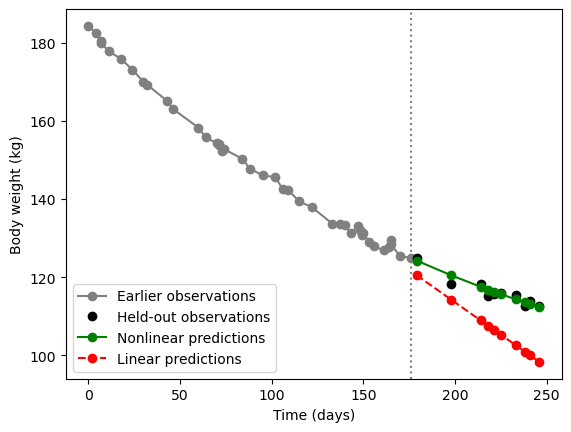

In [43]:
rmse_nonlinear = np.sqrt(np.mean((y_test.to_numpy() - pred_nonlinear) ** 2))
rmse_linear = np.sqrt(np.mean((y_test.to_numpy() - pred_linear) ** 2))
print('Nonlinear test RMSE:', rmse_nonlinear)
print('Linear test RMSE:', rmse_linear)

plt.plot(x_train, y_train, 'o-', color='gray', label='Earlier observations')
plt.plot(x_test, y_test, 'ko', label='Held-out observations')
plt.plot(x_test, pred_nonlinear, 'o-', color='green', label='Nonlinear predictions')
plt.plot(x_test, pred_linear, 'o--', color='red', label='Linear predictions')
plt.axvline(x_train[-1], color='gray', linestyle=':')
plt.xlabel('Time (days)')
plt.ylabel('Body weight (kg)')
plt.legend()
plt.show()

Clearly the nonlinear model gives much better predictions compared to the linear model. 